In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Ahora a cargar los datos de titanic para comenzar a trabajar con ellos!

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_gender = pd.read_csv('gender_submission.csv')

Es importante ver que los datos estén bien antes de comenzar a trabajarlos

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_test.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df_gender.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Se puede observar que hay muchos NaN en la columna cabin, por lo que es mejor eliminarla para el análisis

In [7]:
df_train = df_train.drop(["Cabin"], axis=1)
df_test = df_test.drop(["Cabin"], axis=1)

In [8]:
#Para confirmar que estén eliminadas lo mejor es compropbar las columnas de los df:
print(df_train.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


Es adecuado también rellenar los datos faltantes en "Age" ya que al no ser en su totalidad NaN, si es un hecho el que nos moleste que estos existan para un análisis, por lo que la mejor decisión será rellenar con promedios, así no vemos tan alterados los resultados si quisieramos hacer un análisis por edad. Además, tambien queremos saber donde hay mas datos nulos, por lo que luego de rellenar con los promedios, verificamos por columna si es que pandas nos devuelve algun NaN.

In [9]:
#Primero tenemos que obtener ese promedio
promedio_edad = df_train["Age"].mean()
df_train["Age"].fillna(promedio_edad, inplace=True)
df_test["Age"].fillna(promedio_edad, inplace=True)

C:\Users\nico_\AppData\Local\Temp\ipykernel_23524\2614741824.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Age"].fillna(promedio_edad, inplace=True)
C:\Users\nico_\AppData\Local\Temp\ipykernel_23524\2614741824.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [10]:
pasajeros_sin_embarque = df_train[df_train['Embarked'].isnull()]
pasajeros_sin_embarque

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [11]:
#Tenemos que poner la moda de embarque para rellenar esos 2 NaN que tenemos:
df_train["Embarked"].fillna(df_train["Embarked"].mode()[0], inplace=True)
df_test["Embarked"].fillna(df_test["Embarked"].mode()[0], inplace=True)

C:\Users\nico_\AppData\Local\Temp\ipykernel_23524\1744413980.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Embarked"].fillna(df_train["Embarked"].mode()[0], inplace=True)
C:\Users\nico_\AppData\Local\Temp\ipykernel_23524\1744413980.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [12]:
pasajeros_sin_esposa_hermano = df_train[df_train['SibSp'].isnull()]
pasajeros_sin_esposa_hermano

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [13]:
pasajeros_sin_parientes_hijos = df_train[df_train['Parch'].isnull()]
pasajeros_sin_parientes_hijos

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [14]:
pasajero_sin_tarifa = df_train[df_train['Fare'].isnull()]
pasajero_sin_tarifa

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [15]:
pasajero_sin_nombre = df_train[df_train['Name'].isnull()]
pasajero_sin_nombre

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [16]:
pasajero_sin_ticket = df_train[df_train['Ticket'].isnull()]
pasajero_sin_ticket

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [17]:
pasajero_sin_sexo = df_train[df_train['Sex'].isnull()]
pasajero_sin_sexo

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [18]:
pasajero_sin_clase = df_train[df_train['Pclass'].isnull()]
pasajero_sin_clase

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [19]:
pasajero_sin_id = df_train[df_train['PassengerId'].isnull()]
pasajero_sin_id

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [20]:
pasajero_sin_registro_sionovida = df_train[df_train['Survived'].isnull()]
pasajero_sin_registro_sionovida

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


Ahora que revisamos todos los datos en train, volvemos a verificar que no hayan NaN y comenzamos con el análisis

In [21]:
test_nulos = df_test.isnull().sum()
test_nulos
#Hay uno sin pagar, será jack? jaja

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

In [22]:
test_nulos2 = df_train.isnull().sum()
test_nulos2

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

En primer lugar podemos revisar la cantidad de personas que viajan, para luego ver cual es la edad promedio de las personas que viajan, si son mas jovenes o mas viejas.

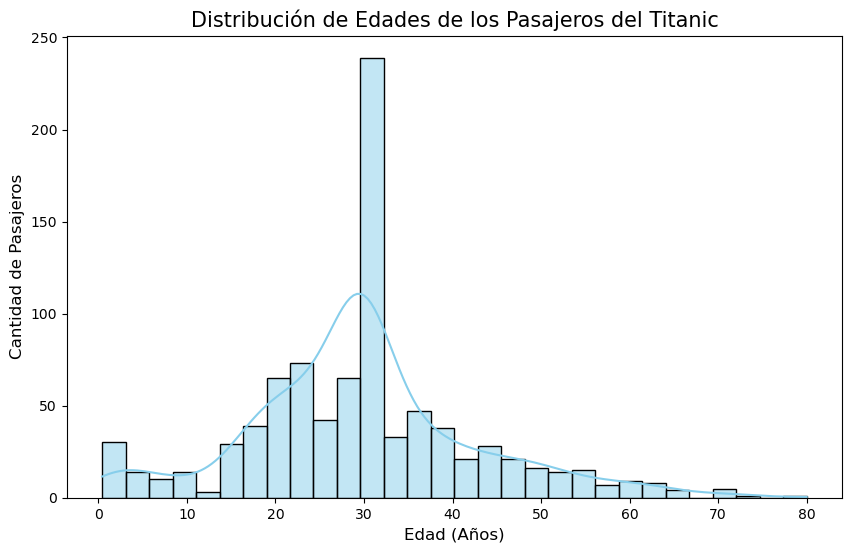

In [23]:
plt.figure(figsize=(10, 6)) #Para definir el tamaño del gráfico
sns.histplot(data=df_train, x='Age', bins=30, kde=True, color='skyblue') #La funcion enseñada en clases para el histograma, acompañada de bins (las barritas) y kde (la linea de tendencia)
plt.title('Distribución de Edades de los Pasajeros del Titanic', fontsize=15) #Título para que no se vea desordenado
plt.xlabel('Edad (Años)', fontsize=12) #Etiqueta para el eje X
plt.ylabel('Cantidad de Pasajeros', fontsize=12) #Etiqueta para el eje Y
plt.show() #Visalizar el gráfico

Se logra ver que hay uan tendencia gigante en los 30 años, pero esto se debe totalmente al promedio que pusimos anteriormente, para esto compobaremos el promedio de las edades y haremos una pequeña tabla que nos muestre el "top 5" para poder verlo de manera mas clara.

In [24]:
#Logramos ver que claramente se debe a lo que llenamos, que fueron un total de lo siguiente:
df_original = pd.read_csv('train.csv')
nulos_originales = df_original.isnull().sum()
print(nulos_originales[nulos_originales > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [25]:
#Y nuestro promedio de edad fue
promedio_edad = df_train["Age"].mean()
promedio_edad
#Por lo que confirmamos que llenamos 177 datos con 29.7, lo que nos dispara la tendencia al medio.


np.float64(29.69911764705882)

In [26]:
#Para seguir trabajando hay que aproximar las edades para que no hayan numeros con decimales en el top que mencionamos:
top_edades = df_train['Age'].round().value_counts().head(5)
tabla_top = pd.DataFrame({'Cantidad de Pasajeros': top_edades})
tabla_top.index.name = 'Edad'
tabla_top

,Cantidad de Pasajeros
Edad,
30.0,204
24.0,32
22.0,27
28.0,27
18.0,26


Podemos ver que igualmente la cantidad de gente con mas representación se mantiene en el rango 18-30, por lo que sí se podría decir que dentro de ese rango es quienes abordaban el barco, esto teniendo en cuenta el contexto también en donde muchos jóvenes buscaban el sueño americano cruzando el atlántico, otros que viajaban por negocios, recordando que, entre los 20 y 30 años en esos tiempos ya existian familias totalmente formadas, personas exitosas en negocios. Por otro lado la gente mayor a esa edad ya se acercaba al máximo de esperanza de vida (35-40 Años en promedio para 1912) por lo que no se podrían ver adultos mayores viajando de vacaciones en cruceros como lo es normalmente a día de hoy, sino más bien quienes lo eran, fueron la excepción...

Ahora sabiendo la edad promedio, tambien es interesante saber si la mayor cantidad eran hombres o mujeres, por lo que hacemos lo siguiente:

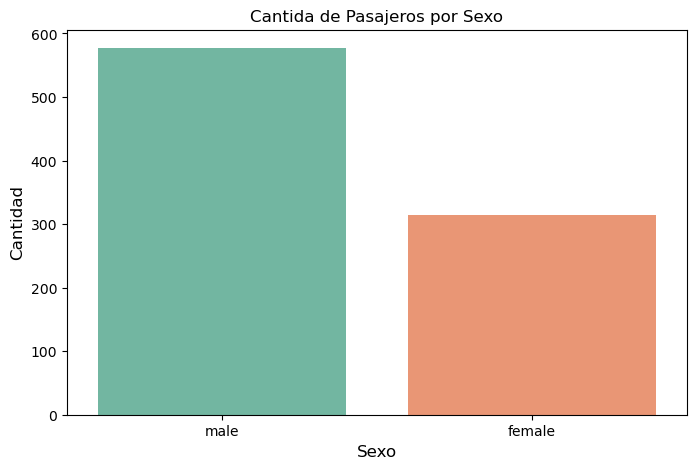

In [27]:
#Nuevamente hacemos la base para el grafico con un tamaño decente:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='Sex', palette='Set2', hue="Sex")
plt.title("Cantida de Pasajeros por Sexo", fontsize= 12)
plt.xlabel("Sexo", fontsize= 12)
plt.ylabel("Cantidad", fontsize= 12)
plt.show()

In [28]:
#Para entenderlo de mejor manera ahora lo que haremos será hacer la misma tabla anterior para ver los números específicos:
tabla_sexo = df_train['Sex'].value_counts()
tabla_sexo

Sex
male      577
female    314
Name: count, dtype: int64

Vemos que claramente existe una mayor cantidad de pasajeros hombres, lo que nos da a entender que estos predominaban en este viaje, esto teniendo en cuenta el contexto histórico, nos hace saber que para ellos era un viaje de negocios y que las mujeres eran las encargadas de cuidar a los menores, o simplemente no viajaban junto a sus maridos porque ellos se negaban a llevar a sus esposas e hijos en el barco.

Ahora es importante ver si existe correlación entre todas las columnas para saber si se salvaron o no, por ejemplo, para poner a prueba la mítica frase de si mujeres y niños primero era real o si solamente fue show para la película.

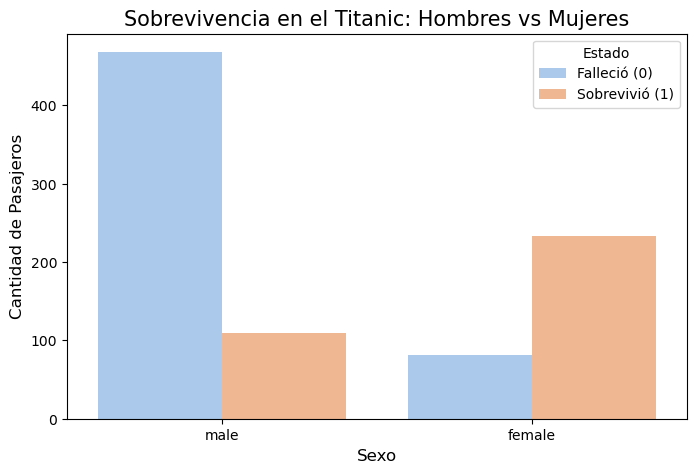


Porcentaje de sobrevivencia por sexo:
Sex
female    74.2 %
male      18.9 %
Name: Survived, dtype: object


In [29]:

plt.figure(figsize=(8, 5)) #Definimos el tamaño del gráfico
sns.countplot(data=df_train, x='Sex', hue='Survived', palette='pastel') #Usamos hue='Survived' para que divida cada barra de sexo en dos colores (vivo/muerto)
plt.title('Sobrevivencia en el Titanic: Hombres vs Mujeres', fontsize=15) #Título para que no se vea desordenado
plt.xlabel('Sexo', fontsize=12) #Etiqueta para el eje X
plt.ylabel('Cantidad de Pasajeros', fontsize=12) #Etiqueta para el eje Y
plt.legend(title='Estado', labels=['Falleció (0)', 'Sobrevivió (1)']) #Leyenda con nombres descriptivos
plt.show()

print("\nPorcentaje de sobrevivencia por sexo:")
porcentaje = df_train.groupby('Sex')['Survived'].mean() * 100
print(porcentaje.round(1).astype(str) + " %")

Tal parece ser que el dicho lleva por delante la verdad, ya que un 74% de las mujeres sobrevivieron frente al 18% de hombres. Teniendo ya este precedente, podemos ver un heatmap para saber si existe alguna correlación entre las variables.

In [30]:
#Ahora lo que haremos será convertir el sexo a números para poder usarlo en el modelo, siendo 0 para hombres y 1 para mujeres:
df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})
df_train[['Name', 'Sex']].head()

,Name,Sex
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,"Allen, Mr. William Henry",0


In [31]:
#Ahora hay q filtrar las columnas solo que contengan números por lo que seleccionamos solo esas columnas:
columnas_numericas = df_train.select_dtypes(include=[np.number]).columns.tolist()
columnas_numericas

['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

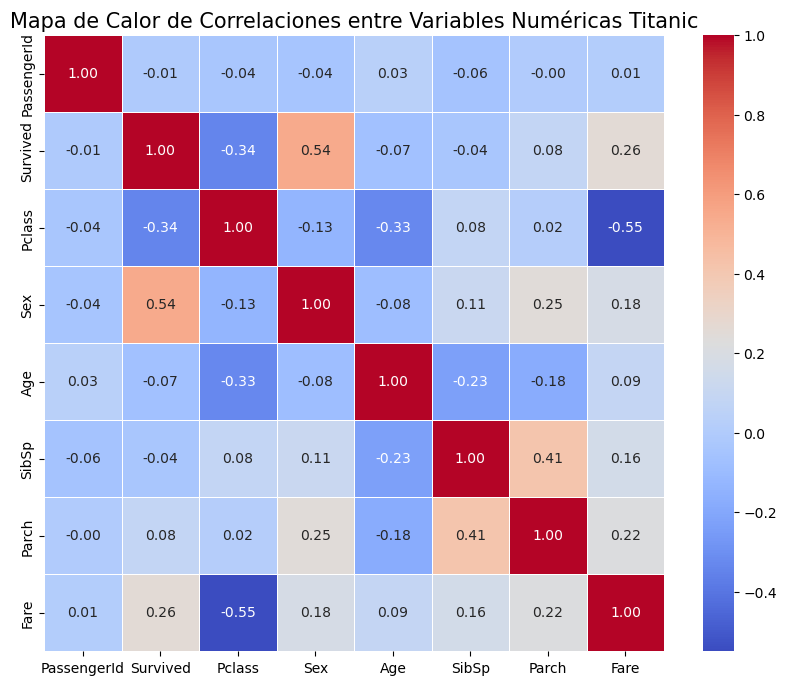

In [32]:
#Finalmente hacemos el heatmap para comparar, teniendo en cuenta que hay que saber interpretar el coeficiente de correlación de pearson para entender la relación entre las variables:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[columnas_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones entre Variables Numéricas Titanic', fontsize=15)
plt.show()

Vemos que claramente se "cumple" en cierta forma el dicho de mujeres y niños primero, aunque princpialmente mujeres, ya que vemos que la edad no es un factor muy significativo, de hecho los más destacables son "Sex" en donde vemos que este es 0.54 lo cual se acerca más a 1, que significa ser mujer y salvarse, también tenemos otros puntos interesantes como el de la clase y el sobrevivir con -0.34, lo que en cierta forma nos indica que mientras más alto sea el número de nuestra clase menos probabilidades de sobrevivir tenemos, esto sabiendo que 1 es adinerados y 3 es ricos, se podría decir que en conjunto con "Fare" que es una corr. positiva 0.26, podemos inferir (no totalmente) que el ser adinerado si influía en sobrevivir o no (tal como se ve en la película, en donde además de niños y mujeres, gente adinerada aseguraba su puesto en el bote). Para esto, también se realizará un gráfico que nos muestre sobrevivientes por clase a ver si realmente esta correlación indica, como tratamos de justificar, una causalidad.

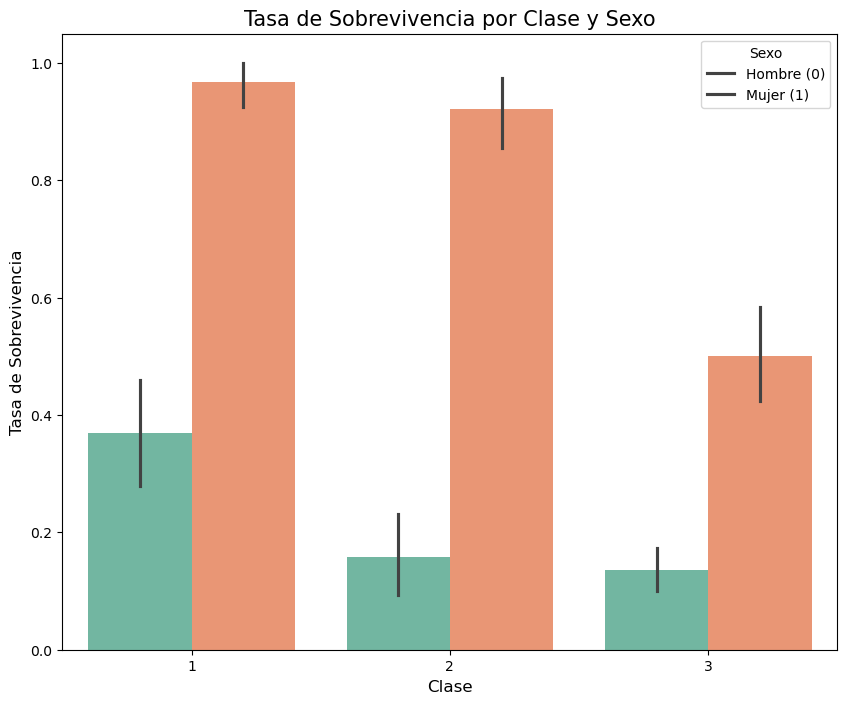

In [34]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_train, x='Pclass', y='Survived', hue='Sex', palette='Set2')
plt.title('Tasa de Sobrevivencia por Clase y Sexo', fontsize=15)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Tasa de Sobrevivencia', fontsize=12)
plt.legend(title='Sexo', labels=['Hombre (0)', 'Mujer (1)'])
plt.show()

Para finalizar podemos observar que al cruzar las variables de clase (Pclass) y sexo (Sex), hay una clara segmentación en las probabilidades de sobrevivir o no, validando nuestra hipotesis inicial que basamos en el dicho "mujeres y niños primero", pero con alta influencia en lo socioeconómico.

1. Sesgo de género: Si no tomamos en cuenta la clase social, las mujeres tal como vimos antes presentan una tasa de supervivencia mayor a la de los hombres, esto se refleja en la correlación positiva observada de 0.54.
2. Influencia de la clase social: Vemos que claramente, mujeres de clase 1 y 2, es decir, quienes poseen recursos, tienen una tasa cercana al 90-95%, mientras que por su lado, las de clase 3, es decir, quienes no poseen tantos recursos, solo llegan a aproximadamente el 50%, lo que nos dice que no solo influye el hecho de ser mujer, sino que al ser mujer Y ADINERADA, su supervivencia era mucho más probable que si no eran adineradas, y peor aún, si no eran mujeres y además pobres.
3. Barras de error: Las líneas negras que vemos en el histograma (intervalos de confianza) nos indican qué tan precisos son nuestros promedios. En la Clase 3, vemos que las líneas son más largas, lo que refleja una mayor variabilidad (hubo mucha gente en situaciones muy distintas). Sin embargo, lo más importante es que los intervalos de las mujeres de Clase 1 y Clase 3 no se cruzan entre sí (es decir no se solapan). Esto es una prueba estadística de que la clase social fue un factor determinante y no una simple casualidad de la muestra.

Por lo tanto podemos decir que el factor más importante es el género de cada persona al momento de estudiar si sobreviven o no, ya que siendo mujer, esta tasa de probabilidad aumentaba de manera drástica. Otro filtro importante como vimos es la clase social, donde los mas adinerados tienden a sobrevivir mas que los "no adinerados", claro ejemplo es que ambas tasas de clase 2 y 3 en hombres, sumadas son practicamente la clase 1, y ni hablar de mujeres, quienes tienen casi 90-95% de chances como se comentó anteriormente. Finalmente pero no menos importante, es que no se tomaron en cuenta factores como la edad dada su baja correlación frente a la supervivencia de las personas, lo mismo con ID, ya que tal como sabemos, es solo un número identificador.